<a href="https://colab.research.google.com/github/Emmanuelkiptim/Digital-Marketing-Performance-Analysis/blob/main/Digital_Marketing_Performance_Analysis_Identifying_Profitable_Channels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The company has been investing in multiple marketing channels but lacks clarity on which campaigns are delivering value. Some campaigns may be consuming a large portion of the budget without generating sufficient conversions or revenue.

Without proper analysis, the marketing team risks continuing to invest in underperforming channels, leading to inefficient use of resources.

This project seeks to evaluate campaign performance and provide actionable recommendations on how to allocate the marketing budget effectively.

# Import Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### import and load the dataset

In [49]:
df=pd.read_csv("Online Marketing Campaign.csv")
df.head()


,date,channel,spend,impressions,clicks,conversions,revenue
0,2024-01-01,Google Ads,230.52,12138,933,103,6066.65
1,2024-01-01,Facebook Ads,325.39,2936,117,5,219.81
2,2024-01-01,Instagram,214.28,2857,157,8,165.35
3,2024-01-01,Email,189.68,2323,245,37,796.06
4,2024-01-02,Google Ads,563.65,3731,285,35,1520.77


1. Data Eyeballing

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2160 non-null   object 
 1   channel      2160 non-null   object 
 2   spend        2160 non-null   float64
 3   impressions  2160 non-null   int64  
 4   clicks       2160 non-null   int64  
 5   conversions  2160 non-null   int64  
 6   revenue      2160 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 118.3+ KB


In [51]:
df.isna().sum()

,0
date,0
channel,0
spend,0
impressions,0
clicks,0
conversions,0
revenue,0


In [52]:
df.describe()
df['channel'].unique()


array(['Google Ads', 'Facebook Ads', 'Instagram', 'Email'], dtype=object)

2. Data Cleaning.

In [53]:
df.dtypes

,0
date,object
channel,object
spend,float64
impressions,int64
clicks,int64
conversions,int64
revenue,float64


In [54]:
## replace date data type
df['date']=pd.to_datetime(df['date'])
df


,date,channel,spend,impressions,clicks,conversions,revenue
0,2024-01-01,Google Ads,230.52,12138,933,103,6066.65
1,2024-01-01,Facebook Ads,325.39,2936,117,5,219.81
2,2024-01-01,Instagram,214.28,2857,157,8,165.35
3,2024-01-01,Email,189.68,2323,245,37,796.06
4,2024-01-02,Google Ads,563.65,3731,285,35,1520.77
...,...,...,...,...,...,...,...
2155,2025-06-22,Email,152.48,9496,802,94,3496.78
2156,2025-06-23,Google Ads,545.81,4536,262,24,1005.36
2157,2025-06-23,Facebook Ads,208.99,3165,82,7,198.85
2158,2025-06-23,Instagram,210.15,5386,264,8,132.71



### The campaign dataset contains of marketing campaign data from instagram, email, facebook and google ads.
### The columns are: date, channel, spend, impressions, clicks, conversions, revenue.
### The data was cleaned enough no missing values were found. I only had to change the date data type from object to datetime.

3. Feature Engineering and Metrics Calculation

In [55]:
df['Click Through Rate']=df['clicks']/df['impressions']
df['Profit Per Ad']=df['revenue']-df['spend']
df['Conversion Rate']=df['conversions']/df['clicks']
df['Return on Ad Spend']=df['revenue']/df['spend']
df


,date,channel,spend,impressions,clicks,conversions,revenue,Click Through Rate,Profit Per Ad,Conversion Rate,Return on Ad Spend
0,2024-01-01,Google Ads,230.52,12138,933,103,6066.65,0.076866,5836.13,0.110397,26.317239
1,2024-01-01,Facebook Ads,325.39,2936,117,5,219.81,0.039850,-105.58,0.042735,0.675528
2,2024-01-01,Instagram,214.28,2857,157,8,165.35,0.054953,-48.93,0.050955,0.771654
3,2024-01-01,Email,189.68,2323,245,37,796.06,0.105467,606.38,0.151020,4.196858
4,2024-01-02,Google Ads,563.65,3731,285,35,1520.77,0.076387,957.12,0.122807,2.698075
...,...,...,...,...,...,...,...,...,...,...,...
2155,2025-06-22,Email,152.48,9496,802,94,3496.78,0.084457,3344.30,0.117207,22.932712
2156,2025-06-23,Google Ads,545.81,4536,262,24,1005.36,0.057760,459.55,0.091603,1.841960
2157,2025-06-23,Facebook Ads,208.99,3165,82,7,198.85,0.025908,-10.14,0.085366,0.951481
2158,2025-06-23,Instagram,210.15,5386,264,8,132.71,0.049016,-77.44,0.030303,0.631501


### Created new calculation metrics that would assist in the analyzing of the data
1. Click Through rate
2. Return on Ad Spend
3. Conversion Rate

#### 4. Explore the data

Channel Performance analysis


In [56]:
channel_summary= df.groupby('channel').agg (
    {
        'Profit Per Ad': 'sum',
        'Return on Ad Spend': 'mean',
        'spend':'sum',
        'revenue':'sum',
        'clicks':'sum',
        'conversions':'sum',

    }
).sort_values(by='Profit Per Ad', ascending=False)
channel_summary

,Profit Per Ad,Return on Ad Spend,spend,revenue,clicks,conversions
channel,,,,,,
Email,2329190.98,41.041047,68645.65,2397836.63,468550,67962
Google Ads,971003.93,6.059614,220788.51,1191792.44,277696,31420
Instagram,373311.85,4.282049,141350.27,514662.12,233563,13560
Facebook Ads,310370.63,3.077562,180787.24,491157.87,183421,13211


Channel Performance Analysis

To assess overall marketing effectiveness, total profit was calculated as the difference between revenue and ad spend for each channel. The data was then aggregated by channel to evaluate total profit, spend, revenue, clicks, and conversions.

Additional metrics such as Return on Ad Spend (ROAS) and conversion rate were computed to measure efficiency and campaign effectiveness.

## Univariate Analysis
To understand each variable before the realtionship

In [57]:
df.describe()

,date,spend,impressions,clicks,conversions,revenue,Click Through Rate,Profit Per Ad,Conversion Rate,Return on Ad Spend
count,2160,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,2024-09-26 12:00:00,283.135032,8610.065741,538.532407,58.404167,2127.522713,0.062193,1844.387681,0.096959,13.615068
min,2024-01-01 00:00:00,50.270000,1630.000000,38.000000,1.000000,12.440000,0.009951,-647.710000,0.007092,0.050904
25%,2024-05-14 18:00:00,166.435000,5171.250000,279.000000,19.000000,540.325000,0.044321,247.720000,0.063334,1.864869
50%,2024-09-26 12:00:00,267.975000,8473.500000,455.500000,38.000000,1227.460000,0.055452,931.215000,0.093339,4.345671
75%,2025-02-08 06:00:00,381.465000,11466.500000,704.250000,76.000000,2676.762500,0.078539,2398.560000,0.131822,12.239729
max,2025-06-23 00:00:00,898.120000,22474.000000,2324.000000,380.000000,20242.060000,0.128961,20083.150000,0.197694,227.657849
std,NaN,144.161193,4161.970582,355.954379,57.615977,2501.255838,0.024682,2545.773472,0.042344,24.612199


# Distribution Plots

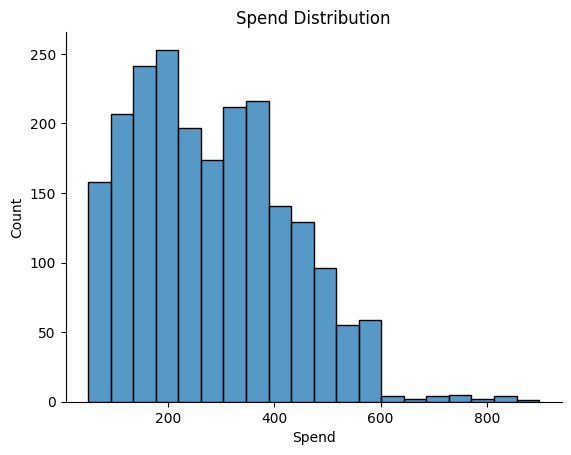

In [58]:
## spend distribution
sns.histplot(data=df, x= 'spend',bins=20)
sns.despine()
plt.xlabel('Spend')
plt.title('Spend Distribution')
plt.show()


The Distribution is rightly skewed meaning that the mean>median

Also noticed the presence of outliers passed the 600 spread

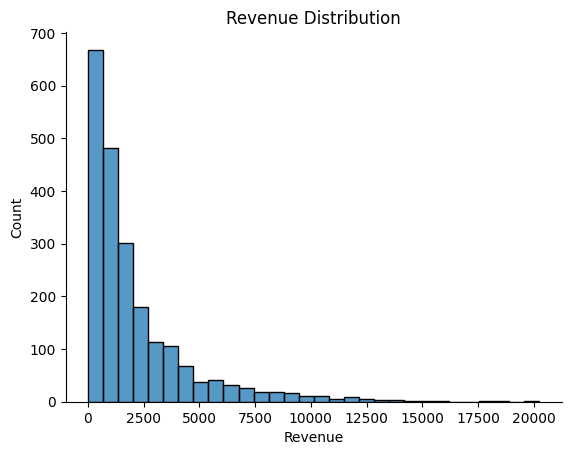

In [59]:
## revenue Distribution
sns.histplot(data=df, x= 'revenue',bins= 30)
sns.despine()
plt.xlabel('Revenue')
plt.title('Revenue Distribution')
plt.show()

Distribution is rightly skewed since mean > median

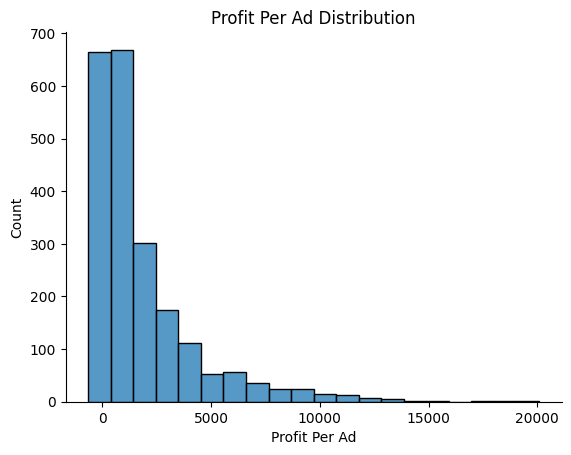

In [60]:
## Profit Distribution
sns.histplot(data=df, x= 'Profit Per Ad',bins=20)
sns.despine()
plt.xlabel('Profit Per Ad')
plt.title('Profit Per Ad Distribution')
plt.show()

The distribution is rightly skewed mean >median

# Categorical Values

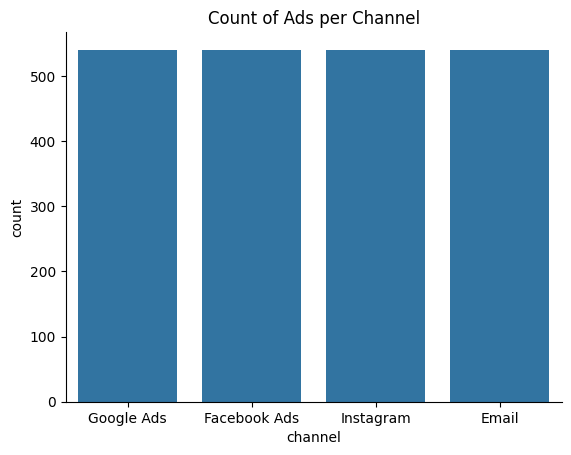

In [61]:
df['channel'].value_counts()

## vizualization of Number of ads per channel
sns.countplot(data=df,x='channel')
sns.despine()
plt.title('Count of Ads per Channel')
plt.show()

Important Ratios

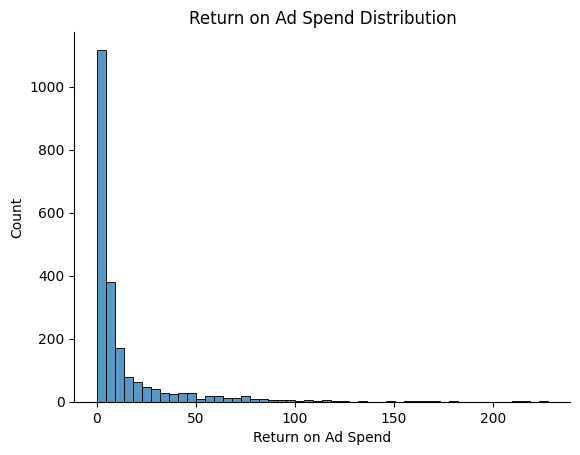

In [62]:
## ROAS Distribution
sns.histplot(data=df,x='Return on Ad Spend',bins=50)
plt.title ('Return on Ad Spend Distribution')
sns.despine()

plt.show()

The distribution is skewed to the right indicating the mean>median
Also this mean spread to the right  is affected by the presence of outliers

## Bivariate Analysis

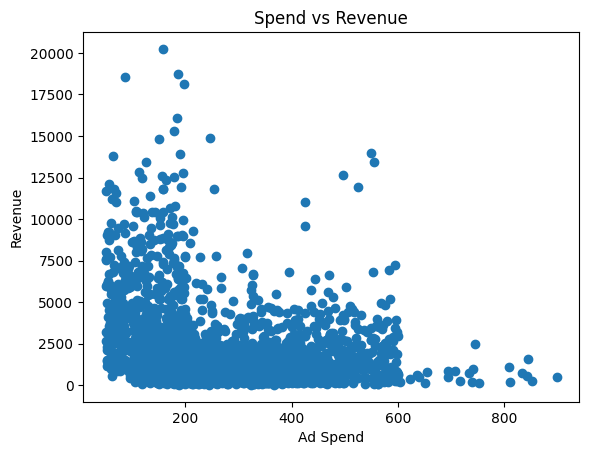

In [63]:
## spend vs revenue
plt.scatter(df['spend'], df['revenue'])
plt.title("Spend vs Revenue")
plt.xlabel("Ad Spend")
plt.ylabel("Revenue")
plt.show()

The relationship between ad spend and revenue appears weak, with no clear linear trend observed. While some campaigns with moderate spend generate high revenue, several high-spend campaigns result in low returns.

<Axes: xlabel='channel', ylabel='Profit Per Ad'>

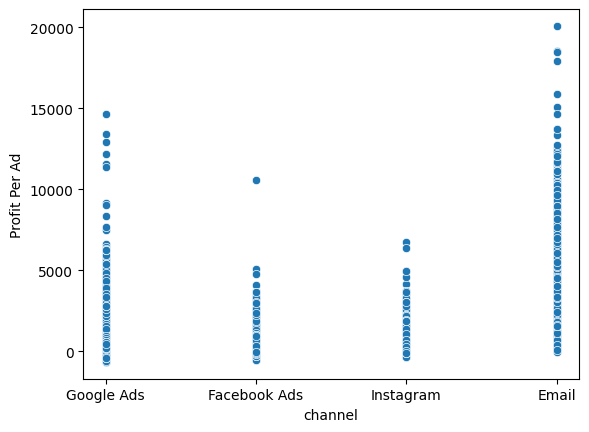

In [64]:
# channel vs profit
sns.scatterplot(data=df,x='channel', y='Profit Per Ad')

Not all channels contribute equally. Email drives the most profit, Facebook has the least profit.

Business insight is to increase budget to email marketing and reduce bugdget allocated to facebook campaigns

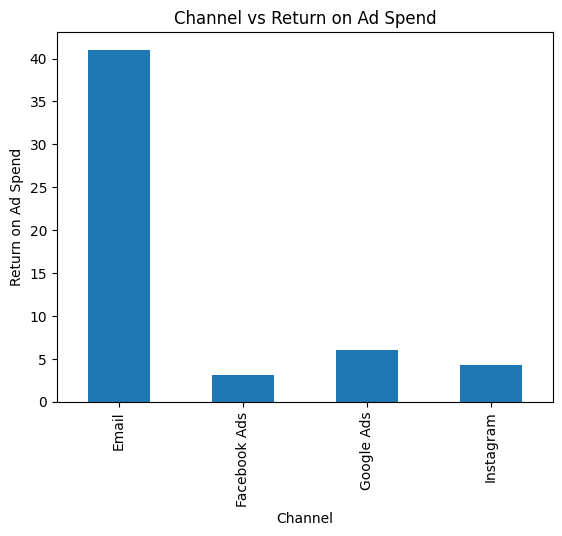

In [65]:
## channel vs roas
df.groupby('channel')['Return on Ad Spend'].mean().plot(kind='bar')
plt.xlabel('Channel')
plt.title('Channel vs Return on Ad Spend')
plt.ylabel('Return on Ad Spend')
plt.show()

The average Return on Ad Spend (ROAS) differs across channels, indicating that some platforms are more efficient in converting ad spend into revenue.

<Axes: xlabel='clicks', ylabel='conversions'>

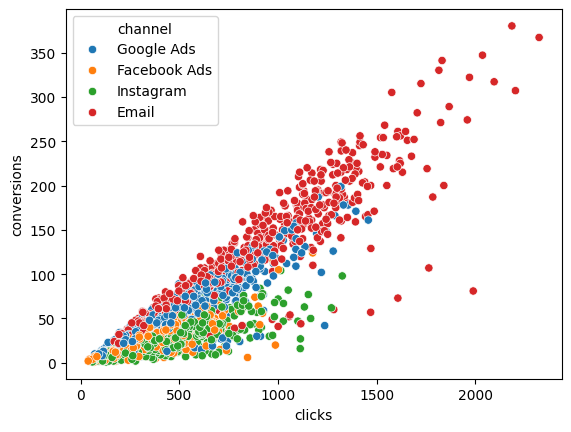

In [66]:
## clicks vs conversions
sns.scatterplot(data=df,x='clicks',y='conversions',hue='channel')

<Axes: xlabel='spend', ylabel='conversions'>

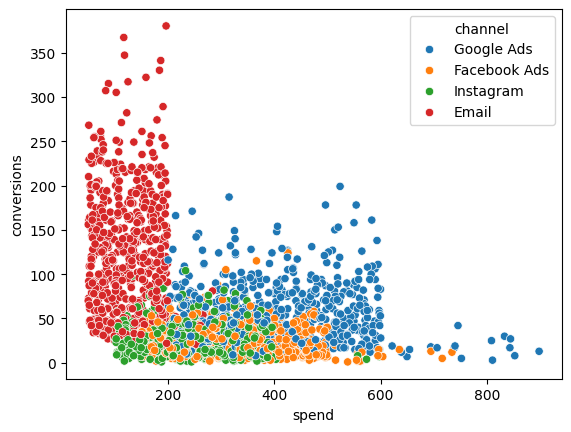

In [67]:
## spend vs conversions
sns.scatterplot(data=df,x='spend',y='conversions',hue='channel')


Email is the best affordable one with at most 200 spend for 350 conversions

While higher spending generally leads to more conversions, the relationship is not consistent across all campaigns, suggesting differences in targeting effectiveness and campaign quality.

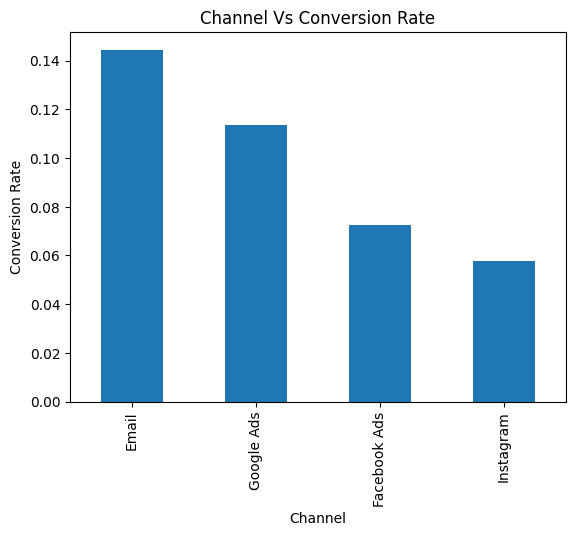

In [68]:
## channel vs conversion rate
df.groupby('channel')['Conversion Rate'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Channel Vs Conversion Rate')
plt.xlabel('Channel')
plt.ylabel('Conversion Rate')
plt.show()



Conversion rates vary across channels, reflecting differences in audience intent and campaign effectiveness. Channels with higher conversion rates are more effective at turning engagement into actual sales.

Multivariate analysis


In [69]:
## correlation analysis
## corr=df[[]]
df.head()



,date,channel,spend,impressions,clicks,conversions,revenue,Click Through Rate,Profit Per Ad,Conversion Rate,Return on Ad Spend
0,2024-01-01,Google Ads,230.52,12138,933,103,6066.65,0.076866,5836.13,0.110397,26.317239
1,2024-01-01,Facebook Ads,325.39,2936,117,5,219.81,0.039850,-105.58,0.042735,0.675528
2,2024-01-01,Instagram,214.28,2857,157,8,165.35,0.054953,-48.93,0.050955,0.771654
3,2024-01-01,Email,189.68,2323,245,37,796.06,0.105467,606.38,0.151020,4.196858
4,2024-01-02,Google Ads,563.65,3731,285,35,1520.77,0.076387,957.12,0.122807,2.698075


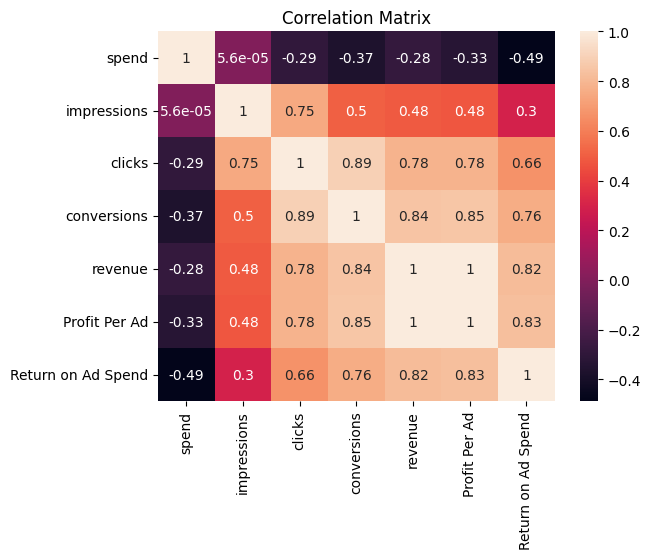

In [70]:
corr= df[['spend', 'impressions', 'clicks', 'conversions', 'revenue','Profit Per Ad', 'Return on Ad Spend']].corr()
corr
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

The correlation analysis reveals strong positive relationships between clicks, conversions, and revenue, indicating that user engagement plays a critical role in driving sales. Campaigns that generate more clicks tend to result in higher conversions and ultimately increased revenue.

However, ad spend shows a weak to negative correlation with key performance metrics such as revenue, profit, and Return on Ad Spend (ROAS). This suggests that higher spending does not necessarily translate into better outcomes and may, in fact, reduce overall efficiency.

Additionally, ROAS is strongly correlated with both revenue and profit but negatively correlated with spend, indicating that the most efficient campaigns are not the ones receiving the highest investment.

Overall, the findings highlight inefficiencies in budget allocation, where increased spending does not guarantee improved performance.

## Time Based Trend Analysis

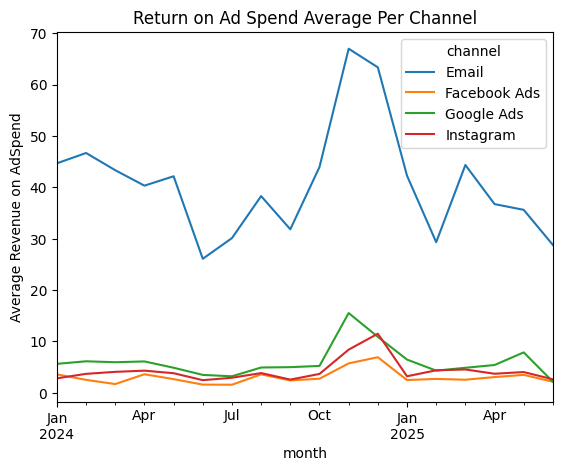

In [71]:
df['month']=df['date'].dt.to_period('M')
monthly_roas=df.groupby(['month','channel'])['Return on Ad Spend'].mean().unstack()
monthly_roas.plot()
plt.title('Return on Ad Spend Average Per Channel')
plt.ylabel('Average Revenue on AdSpend')
plt.show()

Seasonal patterns are observed in the data, with increased performance during peak periods and reduced activity during off-peak months. This suggests that marketing effectiveness is influenced by external factors such as holidays and consumer demand cycles.

In [72]:
## Poor Campaigns
bad_campaigns=df[
    (df['spend']> df['spend'].quantile(0.75))&(df['conversions']<df['conversions'].quantile(0.25))
]
bad_campaigns['channel'].value_counts().reset_index()

,channel,count
0,Facebook Ads,95
1,Google Ads,33
2,Instagram,21


### Several campaigns were identified with high ad spend but low conversion rates, indicating inefficient use of resources.

1. Facebook Ads	95 ads
2. Google Ads	33 ads
3. Instagram	21 ads

# Final Insights
1. Poor Budget Allocation.
The company is overspending on campaigns that are not delivering proportional returns.
2. Market Funnnel is Working.
Strong positive relationships between impressions, clicks, conversions, and revenue indicate that the marketing funnel is functioning effectively.
3. Channel Performance Differences.
Email marketing emerges as the most profitable and consistent channel, while Google Ads shows strong but variable performance. Instagram delivers moderate results, whereas Facebook Ads consistently underperforms.
4. Presence of Inneficient Campaigns.
Several campaigns were identified with high ad spend but low conversion rates.

        1. Facebook Ads	95 ads
        2. Google Ads	33 ads
        3. Instagram	21 ads
5. Seasonal Trends affect campaigns.
Campaign performance varies over time(especiall the 3rd Quater), with certain periods showing improved results. This suggests that customer behavior and demand fluctuate, making timing an important factor in campaign success.


## Recommendation

1. Reallocate budget to high performing Channels
2. Reduce and Pause Low Performing channels
3. Optimize High Spending and Low Performing Channels
4. Focus on other metrics not just spend.